# Churn Analysis

## Data Understanding & Preparation

### Import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

### Load dataset

In [6]:
df = pd.read_csv("../data/TelcoCustomerChurn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Understanding the dataset

In [7]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.describe(include="object")

C:\Users\pranaypradhan\AppData\Local\Temp\ipykernel_24528\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [11]:
df.describe(include="str")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### Checking the missing values

In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: str

In [14]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [15]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [16]:
invalid_total_charges = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).isna()

df.loc[
    invalid_total_charges,
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [17]:
df.loc[invalid_total_charges, "TotalCharges"].value_counts(dropna=False)

TotalCharges
    11
Name: count, dtype: int64

In [18]:
df.loc[invalid_total_charges, "TotalCharges"].map(repr)

488     ' '
753     ' '
936     ' '
1082    ' '
1340    ' '
3331    ' '
3826    ' '
4380    ' '
5218    ' '
6670    ' '
6754    ' '
Name: TotalCharges, dtype: str

In [19]:
df.loc[invalid_total_charges, "tenure"].value_counts()

tenure
0    11
Name: count, dtype: int64

In [20]:
df.loc[invalid_total_charges, ["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [21]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [22]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [23]:
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isna().sum())

float64
0


#### Handling TotalCharges:
TotalCharges was initially stored as a string column. After converting it to numeric, 11 missing values were identified. Further investigation showed that all 11 customers had a tenure of 0 months. This indicates that these customers had not yet accumulated historical charges. Therefore, the missing TotalCharges values were replaced with 0 rather than dropping the records or imputing them using the overall mean/median.

In [25]:
df.loc[
    (df["TotalCharges"].isna()) & (df["tenure"] == 0),
    "TotalCharges"
] = 0

In [26]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [27]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Checking duplicates

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df["customerID"].nunique()

7043

In [30]:
len(df)

7043

#### Droping customerID
For modeling, we will remove customerID because an arbitrary customer identifier usually shouldn't influence churn prediction

In [31]:
df = df.drop(columns=["customerID"])

### Examining the target variable

In [32]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [33]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## Exploratory Data Analysis

### EDA 1: Churn Distribution

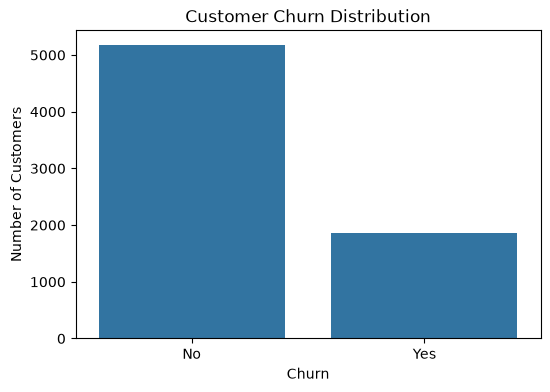

In [36]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

#### Business Insight
The dataset contains more non-churn customers than churn customers. This class distribution should be considered during model evaluation, since accuracy alone may not provide a complete picture of model performance.

### EDA 2: Churn by Contract Type

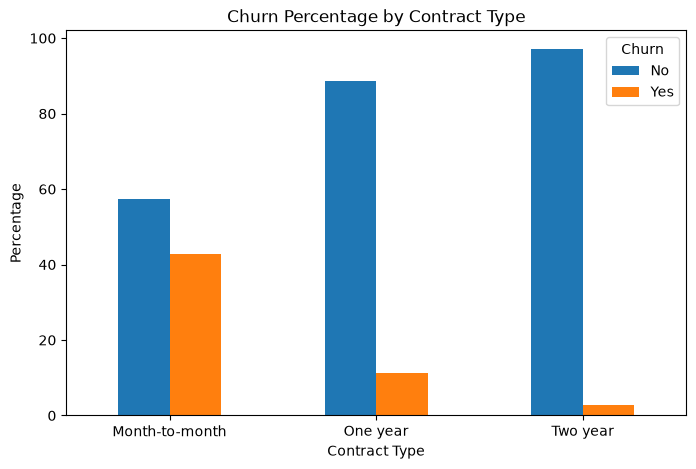

In [37]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

#### Business Insight
Month-to-month contract type has highest proportion of churners.

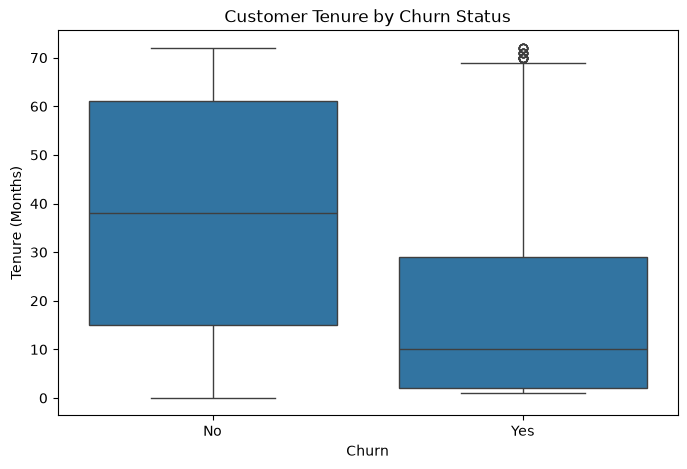

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

#### Business Insight
Generally churned customers have shorter tenure.

### EDA 4: Monthly Charges vs Churn

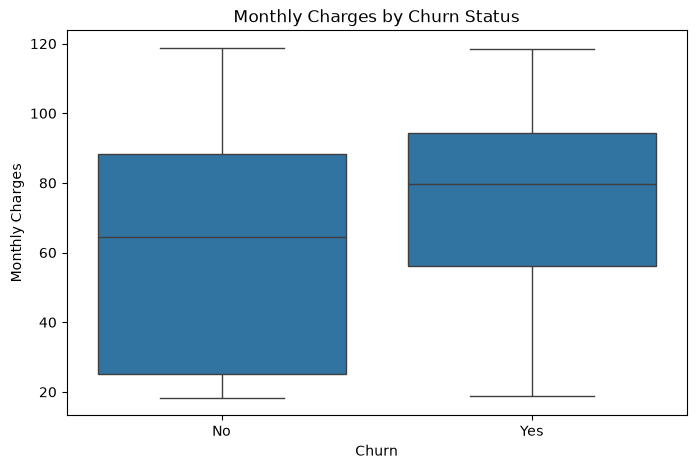

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

#### Business Insight
Higher monthly charges appear to be associated with churn in this dataset.

### EDA 5: Internet Service vs Churn

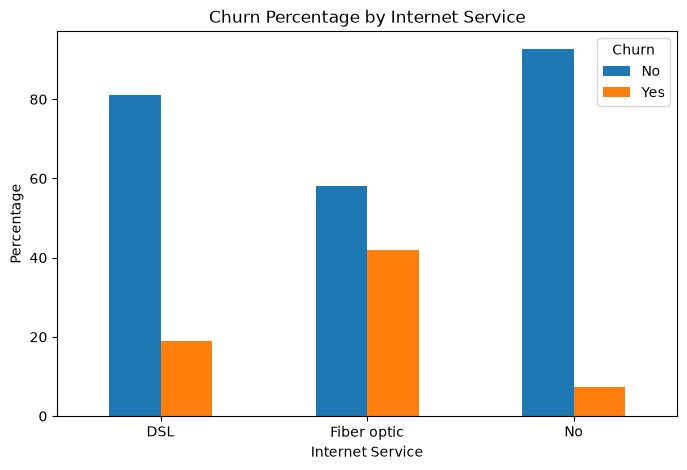

In [40]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Percentage by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

#### Business Insight
Fiber optic Internet service category has the highest observed churn percentage.

### EDA 6: Payment Method vs Churn

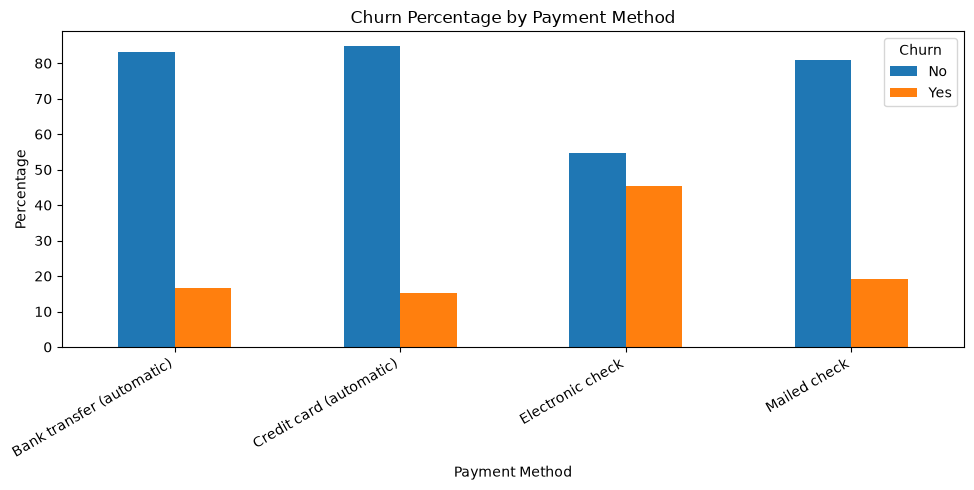

In [41]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Percentage by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

#### Business Insight
Electronic check payment method category has the highest observed churn percentage.

### EDA 7: Tech Support vs Churn

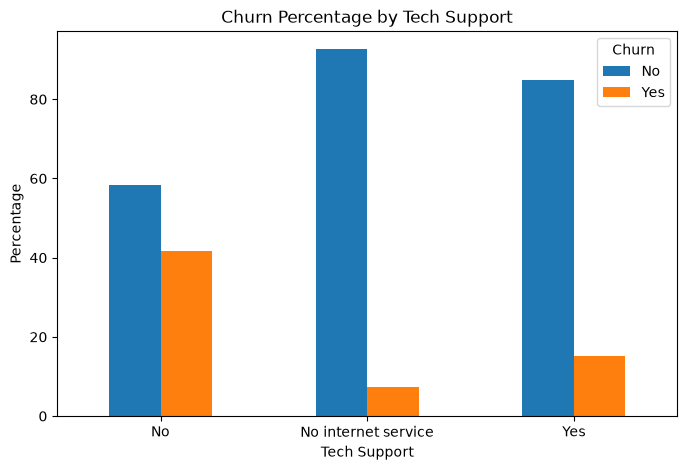

In [42]:
tech_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

tech_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Percentage by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

#### Business Insight
Customers having no technical support service has the highest observed churn percentage.

## Feature Engineering

New features are created from existing customer attributes to provide additional information that may help the model identify churn patterns.

### Feature 1: TotalServices

`TotalServices` represents the number of selected additional services subscribed to by each customer. Combining individual service indicators into a single feature provides a measure of customer service engagement, which may be useful for identifying churn patterns.

In [43]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (df[service_columns] == "Yes").sum(axis=1)

In [44]:
df[service_columns + ["TotalServices"]].head(10)

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,TotalServices
0,No,Yes,No,No,No,No,1
1,Yes,No,Yes,No,No,No,2
2,Yes,Yes,No,No,No,No,2
3,Yes,No,Yes,Yes,No,No,3
4,No,No,No,No,No,No,0
5,No,No,Yes,No,Yes,Yes,3
6,No,Yes,No,No,Yes,No,2
7,Yes,No,No,No,No,No,1
8,No,No,Yes,Yes,Yes,Yes,4
9,Yes,Yes,No,No,No,No,2


In [45]:
df["TotalServices"].value_counts().sort_index()

TotalServices
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

### Feature 2: TenureGroup

`TenureGroup` categorizes customers according to the length of their relationship with the company. This feature allows the model to capture potentially different churn behavior between newer and long-standing customers.


In [46]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 60, float("inf")],
    labels=["0-12", "13-24", "25-48", "49-60", "61+"]
)

In [47]:
df[["tenure", "TenureGroup"]].head(20)

,tenure,TenureGroup
0,1,0-12
1,34,25-48
2,2,0-12
3,45,25-48
4,2,0-12
5,8,0-12
6,22,13-24
7,10,0-12
8,28,25-48
9,62,61+


In [48]:
df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-12     2186
13-24    1024
25-48    1594
49-60     832
61+      1407
Name: count, dtype: int64

In [49]:
df[["tenure", "TenureGroup", "TotalServices"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   tenure         7043 non-null   int64   
 1   TenureGroup    7043 non-null   category
 2   TotalServices  7043 non-null   int64   
dtypes: category(1), int64(2)
memory usage: 117.3 KB


In [50]:
df[["tenure", "TotalServices"]].describe()

,tenure,TotalServices
count,7043.000000,7043.000000
mean,32.371149,2.037910
std,24.559481,1.847682
min,0.000000,0.000000
25%,9.000000,0.000000
50%,29.000000,2.000000
75%,55.000000,3.000000
max,72.000000,6.000000


In [51]:
df[["TenureGroup", "TotalServices"]].isna().sum()

TenureGroup      0
TotalServices    0
dtype: int64

## Model Development

### Prepare X and y

In [52]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [53]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 21)
y shape: (7043,)


In [54]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TotalServices,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,1,0-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,2,25-48
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,2,0-12
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,3,25-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0-12


In [55]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: str

In [56]:
"customerID" in X.columns

False

### 70/30 Train-Test Split

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [59]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (4930, 21)
Testing features: (2113, 21)
Training target: (4930,)
Testing target: (2113,)


In [60]:
print("Training churn distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True))

Training churn distribution:
Churn
No     0.734686
Yes    0.265314
Name: proportion, dtype: float64

Testing churn distribution:
Churn
No     0.734501
Yes    0.265499
Name: proportion, dtype: float64


### Verifying training/testing distributions

In [61]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (4930, 21)
X_test shape: (2113, 21)

Training target distribution:
Churn
No     0.734686
Yes    0.265314
Name: proportion, dtype: float64

Testing target distribution:
Churn
No     0.734501
Yes    0.265499
Name: proportion, dtype: float64


In [62]:
X_train.dtypes

gender                   str
SeniorCitizen          int64
Partner                  str
Dependents               str
tenure                 int64
PhoneService             str
MultipleLines            str
InternetService          str
OnlineSecurity           str
OnlineBackup             str
DeviceProtection         str
TechSupport              str
StreamingTV              str
StreamingMovies          str
Contract                 str
PaperlessBilling         str
PaymentMethod            str
MonthlyCharges       float64
TotalCharges         float64
TotalServices          int64
TenureGroup         category
dtype: object

In [63]:
numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


### Building the preprocessing pipeline

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [65]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [66]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

In [67]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Creating Decision Tree Model 1

In [68]:
from sklearn.tree import DecisionTreeClassifier

In [69]:
model_1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

In [70]:
model_1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['gender','SeniorCitizen','Partner',...,'TotalCharges','TotalServices', 'TenureGroup']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [71]:
y_pred_1 = model_1.predict(X_test)

### Evaluating Model 1

In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_pred_1 = model_1.predict(X_test)

print("Model 1 Results")
print("----------------")
print("Accuracy :", accuracy_score(y_test, y_pred_1))
print("Precision:", precision_score(y_test, y_pred_1, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred_1, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, y_pred_1, pos_label="Yes"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_1))

Model 1 Results
----------------
Accuracy : 0.7330809275911027
Precision: 0.49731663685152055
Recall   : 0.49554367201426025
F1 Score : 0.49642857142857144

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.82      0.82      1552
         Yes       0.50      0.50      0.50       561

    accuracy                           0.73      2113
   macro avg       0.66      0.66      0.66      2113
weighted avg       0.73      0.73      0.73      2113



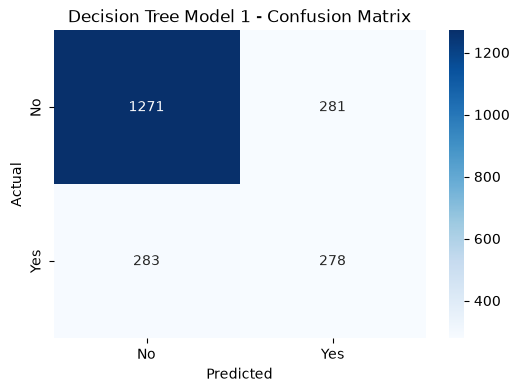

In [77]:
cm1 = confusion_matrix(
    y_test,
    y_pred_1,
    labels=["No", "Yes"]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Decision Tree Model 1 - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Creating Decision Tree Model 2

In [78]:
model_2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42
        ))
    ]
)

In [79]:
model_2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['gender','SeniorCitizen','Partner',...,'TotalCharges','TotalServices', 'TenureGroup']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [80]:
y_pred_2 = model_2.predict(X_test)

### Evaluating Model 2

In [81]:
print("Model 2 Results")
print("----------------")
print("Accuracy :", accuracy_score(y_test, y_pred_2))
print("Precision:", precision_score(y_test, y_pred_2, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred_2, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, y_pred_2, pos_label="Yes"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_2))

Model 2 Results
----------------
Accuracy : 0.7941315664931378
Precision: 0.6145454545454545
Recall   : 0.6024955436720143
F1 Score : 0.6084608460846085

Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.86      0.86      1552
         Yes       0.61      0.60      0.61       561

    accuracy                           0.79      2113
   macro avg       0.74      0.73      0.73      2113
weighted avg       0.79      0.79      0.79      2113



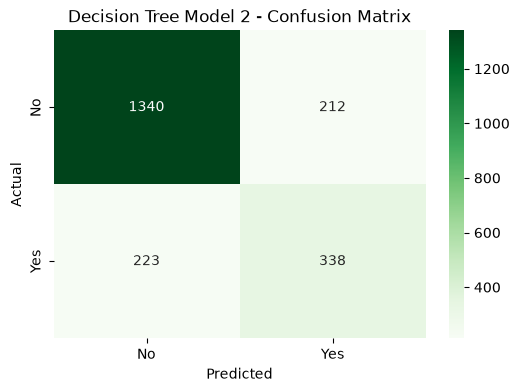

In [82]:
cm2 = confusion_matrix(
    y_test,
    y_pred_2,
    labels=["No", "Yes"]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Decision Tree Model 2 - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Evaluation

### Comparing both models

In [83]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree 1 - Baseline",
        "Decision Tree 2 - Controlled"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_1),
        accuracy_score(y_test, y_pred_2)
    ],
    "Precision": [
        precision_score(y_test, y_pred_1, pos_label="Yes"),
        precision_score(y_test, y_pred_2, pos_label="Yes")
    ],
    "Recall": [
        recall_score(y_test, y_pred_1, pos_label="Yes"),
        recall_score(y_test, y_pred_2, pos_label="Yes")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_1, pos_label="Yes"),
        f1_score(y_test, y_pred_2, pos_label="Yes")
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree 1 - Baseline,0.733081,0.497317,0.495544,0.496429
1,Decision Tree 2 - Controlled,0.794132,0.614545,0.602496,0.608461


In [84]:
results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree 1 - Baseline,0.733,0.497,0.496,0.496
1,Decision Tree 2 - Controlled,0.794,0.615,0.602,0.608


### Model Comparison and Selection

The controlled Decision Tree (Model 2) performed better than the baseline Decision Tree across all evaluated test metrics.

Model 1 achieved an accuracy of 73.3%, precision of 49.7%, recall of 49.6%, and F1 score of 49.6%.

Model 2 improved the results to 79.4% accuracy, 61.5% precision, 60.2% recall, and 60.8% F1 score.

Recall is particularly important for this churn prediction problem because a false negative represents a customer who actually churns but is predicted as a non-churner. Such customers may be missed by potential retention initiatives.

Based on its stronger overall test performance and improved ability to identify churners, Model 2 was selected as the final Decision Tree model.

### Checking for overfitting

In [85]:
print(
    "Model 1 Training Accuracy:",
    model_1.score(X_train, y_train)
)

print(
    "Model 1 Testing Accuracy:",
    model_1.score(X_test, y_test)
)

print(
    "\nModel 2 Training Accuracy:",
    model_2.score(X_train, y_train)
)

print(
    "Model 2 Testing Accuracy:",
    model_2.score(X_test, y_test)
)

Model 1 Training Accuracy: 0.9979716024340771
Model 1 Testing Accuracy: 0.7330809275911027

Model 2 Training Accuracy: 0.801419878296146
Model 2 Testing Accuracy: 0.7941315664931378


### Overfitting Analysis and Final Model Selection

The baseline Decision Tree achieved a training accuracy of approximately 99.8% but only 73.3% accuracy on the test set. The large difference between training and testing performance indicates that the unrestricted tree is overfitting the training data and does not generalize well to unseen customers.

The controlled Decision Tree achieved approximately 80.1% training accuracy and 79.4% testing accuracy. The small difference between these values indicates substantially better generalization.

The controlled model also outperformed the baseline model across the test-set evaluation metrics, achieving approximately 61.5% precision, 60.2% recall, and a 60.8% F1 score for the churn class.

Therefore, Model 2 was selected as the final Decision Tree model because it demonstrates better generalization and stronger performance for identifying customers who churn.

## Model Interpretation

### Feature Importance

In [92]:
final_model = model_2

classifier = final_model.named_steps["classifier"]
preprocessor_fitted = final_model.named_steps["preprocessor"]

In [93]:
feature_names = preprocessor_fitted.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print("Number of feature importances:", len(classifier.feature_importances_))

Number of transformed features: 51
Number of feature importances: 51


#### Creating the importance table

In [94]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": classifier.feature_importances_
})

feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
37,Contract_Month-to-month,0.516048
1,tenure,0.178237
17,InternetService_Fiber optic,0.154221
44,PaymentMethod_Electronic check,0.032261
2,MonthlyCharges,0.024253
28,TechSupport_No,0.023905
3,TotalCharges,0.023050
13,MultipleLines_No,0.016229
19,OnlineSecurity_No,0.010221
36,StreamingMovies_Yes,0.007825


### Top 15 Features Influencing Customer Churn

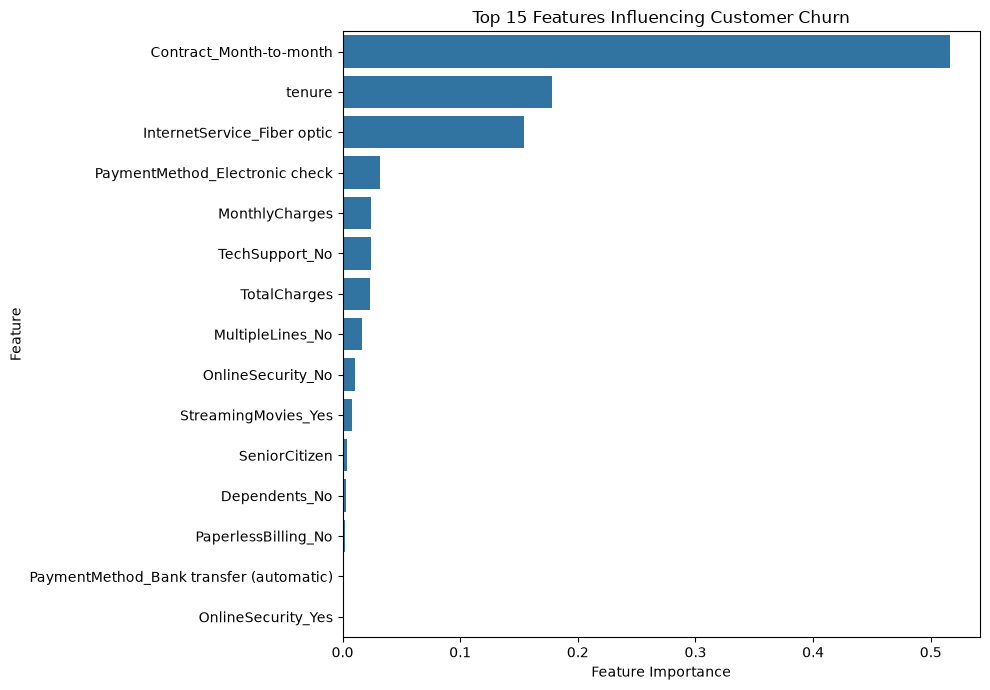

In [95]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Feature Importance and Business Interpretation

The feature importance analysis shows that contract type, particularly a month-to-month contract, is the most influential feature used by the selected Decision Tree model.

Customer tenure and fiber-optic internet service are also among the strongest predictors. Other features used by the model include electronic-check payment, monthly charges, absence of technical support, and total charges.

The strong importance of contract type suggests that the customer's contractual relationship is highly relevant to the model's churn predictions. Tenure indicates that the length of the customer relationship also provides significant predictive information.

These findings can help the business identify customer segments that may warrant additional attention in retention strategies. However, feature importance represents the predictive contribution of a variable within this particular Decision Tree and should not be interpreted as evidence that a feature directly causes customer churn.

This result is consistent with the exploratory analysis, where customers on month-to-month contracts exhibited a higher observed churn rate than customers on longer-term contracts.

### Visualizing the Decision Tree

In [96]:
from sklearn.tree import plot_tree

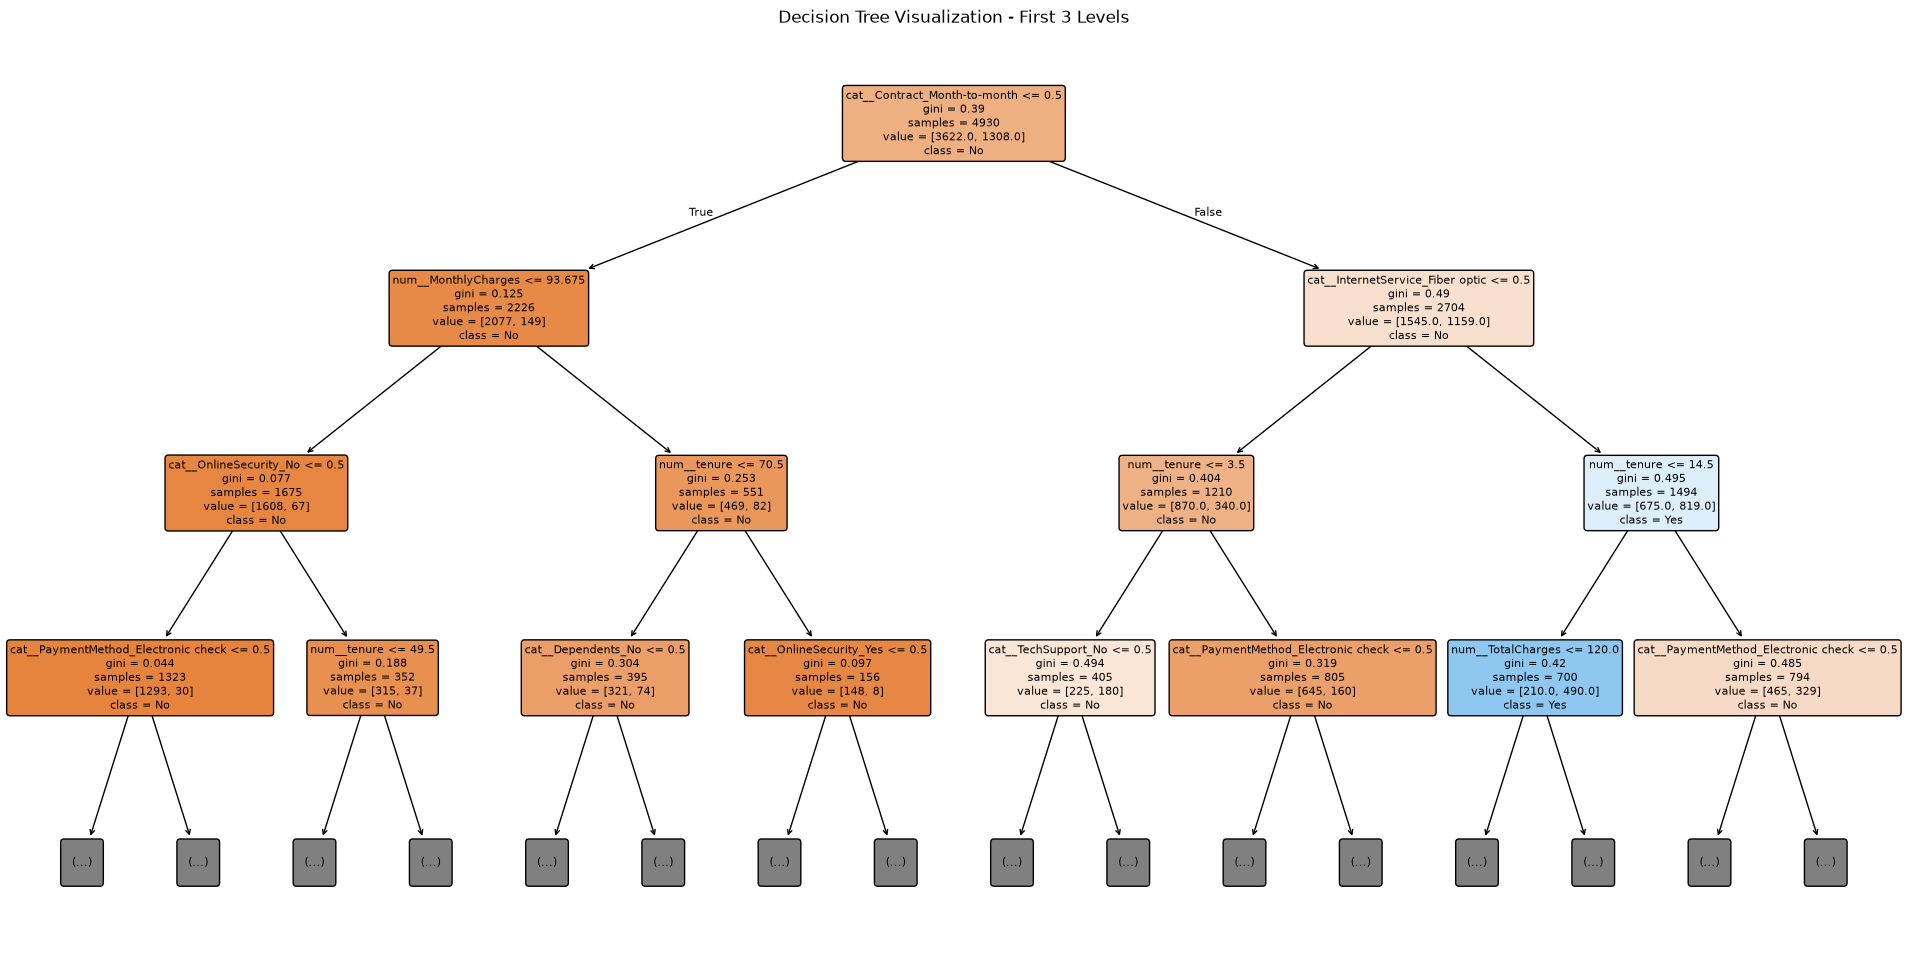

In [97]:
plt.figure(figsize=(24, 12))

plot_tree(
    classifier,
    feature_names=feature_names,
    class_names=classifier.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization - First 3 Levels")
plt.show()

## Model Saving

### Saving the final pipeline

#### Importing Joblib and Path

In [98]:
import joblib
from pathlib import Path

#### Create the model directory if necessary

In [99]:
model_path = Path("../model")
model_path.mkdir(parents=True, exist_ok=True)

#### Saving Model 2

In [100]:
joblib.dump(
    model_2,
    model_path / "churn_model.pkl"
)

['..\\model\\churn_model.pkl']

### Verifying the saved model

In [101]:
loaded_model = joblib.load("../model/churn_model.pkl")

loaded_predictions = loaded_model.predict(X_test)

print(loaded_predictions[:10])

['Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No']


In [102]:
import numpy as np

np.array_equal(
    loaded_predictions,
    model_2.predict(X_test)
)

True

In [103]:
loaded_model.predict_proba(X_test.head())

array([[0.47527473, 0.52472527],
       [0.98921251, 0.01078749],
       [0.47527473, 0.52472527],
       [0.98921251, 0.01078749],
       [0.98921251, 0.01078749]])

In [104]:
print(loaded_model.named_steps.keys())

dict_keys(['preprocessor', 'classifier'])


### Model Persistence

The selected Decision Tree pipeline was serialized using Joblib.

The complete pipeline was saved rather than only the Decision Tree classifier. This ensures that the same preprocessing and categorical encoding used during model training are automatically applied to new customer data during prediction.

After saving, the pipeline was loaded again and its predictions were compared with the original model to verify successful model persistence.